This is exactly the kind of deep hardware understanding that will make your paper stand out. When you write your analysis, breaking down the 3DGS pipeline into distinct computational phases proves to the reviewers that you understand *why* the hardware is failing, not just *that* it failed.

Here is the factual breakdown of the 3D Gaussian Splatting training loop, phase by phase, and exactly how each one abuses the GPU.

### Phase 1: Initialization & Host-to-Device Transfer

Before the loop even starts, the system loads the sparse point cloud generated by COLMAP and initializes the initial 3D Gaussians (Position, Covariance, Opacity, and Spherical Harmonics).

* **GPU Effect (VRAM Floor):** This dictates your starting VRAM footprint. The data is pushed from system RAM (Host) to GPU VRAM (Device).
* **Utilization & Power:** Negligible. The CUDA cores are mostly idle here while memory is allocated. On your graph, this is the flat, low-memory starting line before the training actually begins.

### Phase 2: The Forward Pass (Projection & Rasterization)

This is where the math happens. The GPU projects the 3D Gaussians into 2D camera space. 3DGS uses a highly optimized, tile-based CUDA rasterizer. It divides the screen into 16x16 pixel tiles, assigns Gaussians to those tiles, and uses an extremely fast Radix Sort to order them by depth before alpha-blending them into an image.

* **GPU Effect (The Utilization Spiker):** This phase is why your GPU utilization was pegged at 90% to 100%. The Radix sorting and tile-rendering aggressively saturate the GPU's CUDA cores and memory bandwidth.
* **Power Draw:** This is where your power draw (Watts) hits its peak because the silicon is fully lit up and doing active floating-point math.

### Phase 3: Loss Computation & The Backward Pass

Once the 2D image is rendered, PyTorch compares it to the ground truth photograph using L1 and D-SSIM loss. Then, it runs backpropagation to calculate the gradients (how much each Gaussian needs to move, stretch, or change color to make the image better).

* **GPU Effect (The VRAM Bloat):** Backpropagation is incredibly VRAM-hungry. PyTorch must save the intermediate states (the computational graph) from the Forward Pass to calculate the gradients.
* **The Hardware Reality:** This is why a model that only takes 1GB of VRAM to *render* (inference) will easily consume 8GB of VRAM to *train*. The gradients and optimizer states (usually Adam) take up massive amounts of memory.

### Phase 4: Adaptive Density Control (Densification & Pruning)

This is the "Boss Fight" of 3DGS hardware constraints. Every N iterations (usually every 100 steps), the algorithm evaluates the gradients. If a Gaussian is too transparent, it is pruned (deleted). If a Gaussian has a high positional gradient (meaning it is trying to cover too much complex geometry), the algorithm either **clones** it or **splits** it into smaller Gaussians.

* **GPU Effect (The OOM Crusher):** This is the exact phase that killed your `Tank` and `Temple` datasets. As the scene densifies, the total number of parameters physically multiplies.
* **The Hardware Reality:** The VRAM requirement does not stay flat; it scales dynamically as the algorithm adds hundreds of thousands of new points. When the total parameter count exceeds the physical memory allocator boundary (e.g., 6GB, 8GB, or 12GB), the GPU cannot safely store the new points or their massive backward-pass gradients, resulting in the sudden, catastrophic flatlines on your graphs.

By understanding these four phases, you can definitively state in your paper that your hardware crashes were not caused by a lack of computational power (CUDA cores), but strictly by the VRAM threshold being breached during the **Adaptive Density Control** phase.

### Sequential Order of Phases

In every single training step, the micro-level execution follows this exact linear sequence:

1. **Phase 1: Initialization & Host-to-Device Transfer** (Happens once at the very beginning).
2. **Phase 2: The Forward Pass (Projection & Rasterization)** (Repeats every iteration).
3. **Phase 3: Loss Computation & The Backward Pass** (Repeats every iteration).
4. **Phase 4: Adaptive Density Control (Densification & Pruning)** (Triggers on a macro schedule).

---

### Execution Timeline Across 30,000 Iterations

Here is exactly how these four phases are distributed across your 30k training lifecycle based on the standard 3DGS implementation (Kerbl et al.):

* **Iteration 0 (The Start): Phase 1 (Initialization)**
* Executes exactly once. It allocates the initial VRAM floor for your sparse point cloud and sets up the baseline tensors before any optimization begins.


* **Iterations 1 to 30,000 (Every Step): Phase 2 & Phase 3 (Forward & Backward)**
* These two run back-to-back as a continuous loop for all 30k steps. Every single second, Phase 2 spikes your GPU utilization to 100% via tile-sorting math, and Phase 3 continuously hogs your VRAM to accumulate the backward gradients and Adam optimizer states.


* **Iterations 500 to 15,000 (The Danger Zone): Phase 4 (Densification & Pruning)**
* This phase **does not** run every iteration. It periodically injects itself into the loop **every 100 iterations** (e.g., step 500, 600, 700... up to 15k).
* During this window, Phase 4 dynamically clones and splits Gaussians, physically forcing your VRAM usage to scale upward in a staircase pattern.


* **Iterations 15,001 to 30,000 (The Plateau): Phase 2 & Phase 3 Only**
* Densification completely shuts off at iteration 15,000. For the final 15k steps, the number of Gaussians is completely locked. The GPU stops adding new parameters and spends the remaining time purely fine-tuning colors and positions. This is why VRAM usage flatlines and stabilizes during the second half of training.

In [1]:
%matplotlib inline
from IPython.display import display
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scienceplots

In [2]:

# Dataset Meta data

datasets = {
    "tank": {
        "name":"tank",
        "source":"tanks and temples",
        "resolution": {"width":4300,
                                "height":2189
                                },
        "Points at initialization":206583
    },
    "temple" :{
        "name":"temple",
        "source":"tanks and temples",
        "resolution": {"width":1954,
                                "height":1090
                                },
        "Points at initialization":115017
    },
    "ballroom" :{
        "name":"ballroom",
        "source":"mip-nerf360",
        "resolution": {"width":1957,
                                "height":1091
                                },
        "Points at initialization":207008
    }
}


In [3]:


root = Path("custom-pipeline/Benchmarking/GPU_logs")

def gpu_csv(df:pd.DataFrame,header:str,error):
    prefix = ("cudaoom_","exceeded_")
    header = header.removeprefix(prefix[0])
    header = header.removeprefix(prefix[1])
    stripped = header.split("_")
    dataset_metadata = datasets[stripped[0].casefold()]
    graphics_card = stripped[1].upper()
    vram = str(int(stripped[2].replace("G",""))*1024)+" MiB"
    time_taken = df.Time_Minutes.max()
    resolution = (1/int(stripped[3]))
    memory = df.Memory_Used_MiB.mean()/(time_taken*60)
    
    print(f"""
          Dataset Name: {dataset_metadata["name"]}
          GPU: {graphics_card}
          Video Memory: {vram}
          Time Taken: {time_taken}
          Resolution: {resolution} of {dataset_metadata["resolution"]["width"]} x {dataset_metadata["resolution"]["height"]} ({int(dataset_metadata["resolution"]["width"]*resolution)} x {int(dataset_metadata["resolution"]["height"]*resolution)})
          {f"Error: {error}" if len(error)>0 else "" }
          """)
    return df
    
def results_csv(df,header:str):
    stripped = header.split("_")
    del stripped[0]
    
    print(f"{stripped[0].title()} {stripped[1].upper()} x{1/int(stripped[3])}")
    display(df.sort_values("Iterations"))
    return df

def router(csv_path:Path):
    if not csv_path.exists():
        if (csv_path.parent / ("cudaoom_" + csv_path.name)).exists():
            csv_path = (csv_path.parent / ("cudaoom_" + csv_path.name))
        elif (csv_path.parent / ("exceeded_" + csv_path.name)).exists():
            csv_path = (csv_path.parent / ("exceeded_" + csv_path.name))
        else:
            print(f"csv {csv_path.name} cannot be found")
            return Path()
    
    df = pd.read_csv(csv_path)
    results_shape = (6,4)
    if df.shape != results_shape:
        error = csv_path.stem.split("_")[0]
        error = error if error in ("cudaoom".casefold(),"exceeded".casefold()) else ""
        return gpu_csv(df,csv_path.stem,error)
    else:
        return results_csv(df,csv_path.stem)
    
def get_data(dataset_name:str):
    csvs = pd.DataFrame([file.name for file in root.glob(f"*{dataset_name.casefold()}*.csv")])
    display(csvs)



          Dataset Name: ballroom
          GPU: L4
          Video Memory: 24576 MiB
          Time Taken: 57.7276
          Resolution: 0.5 of 1957 x 1091 (978 x 545)
          
          


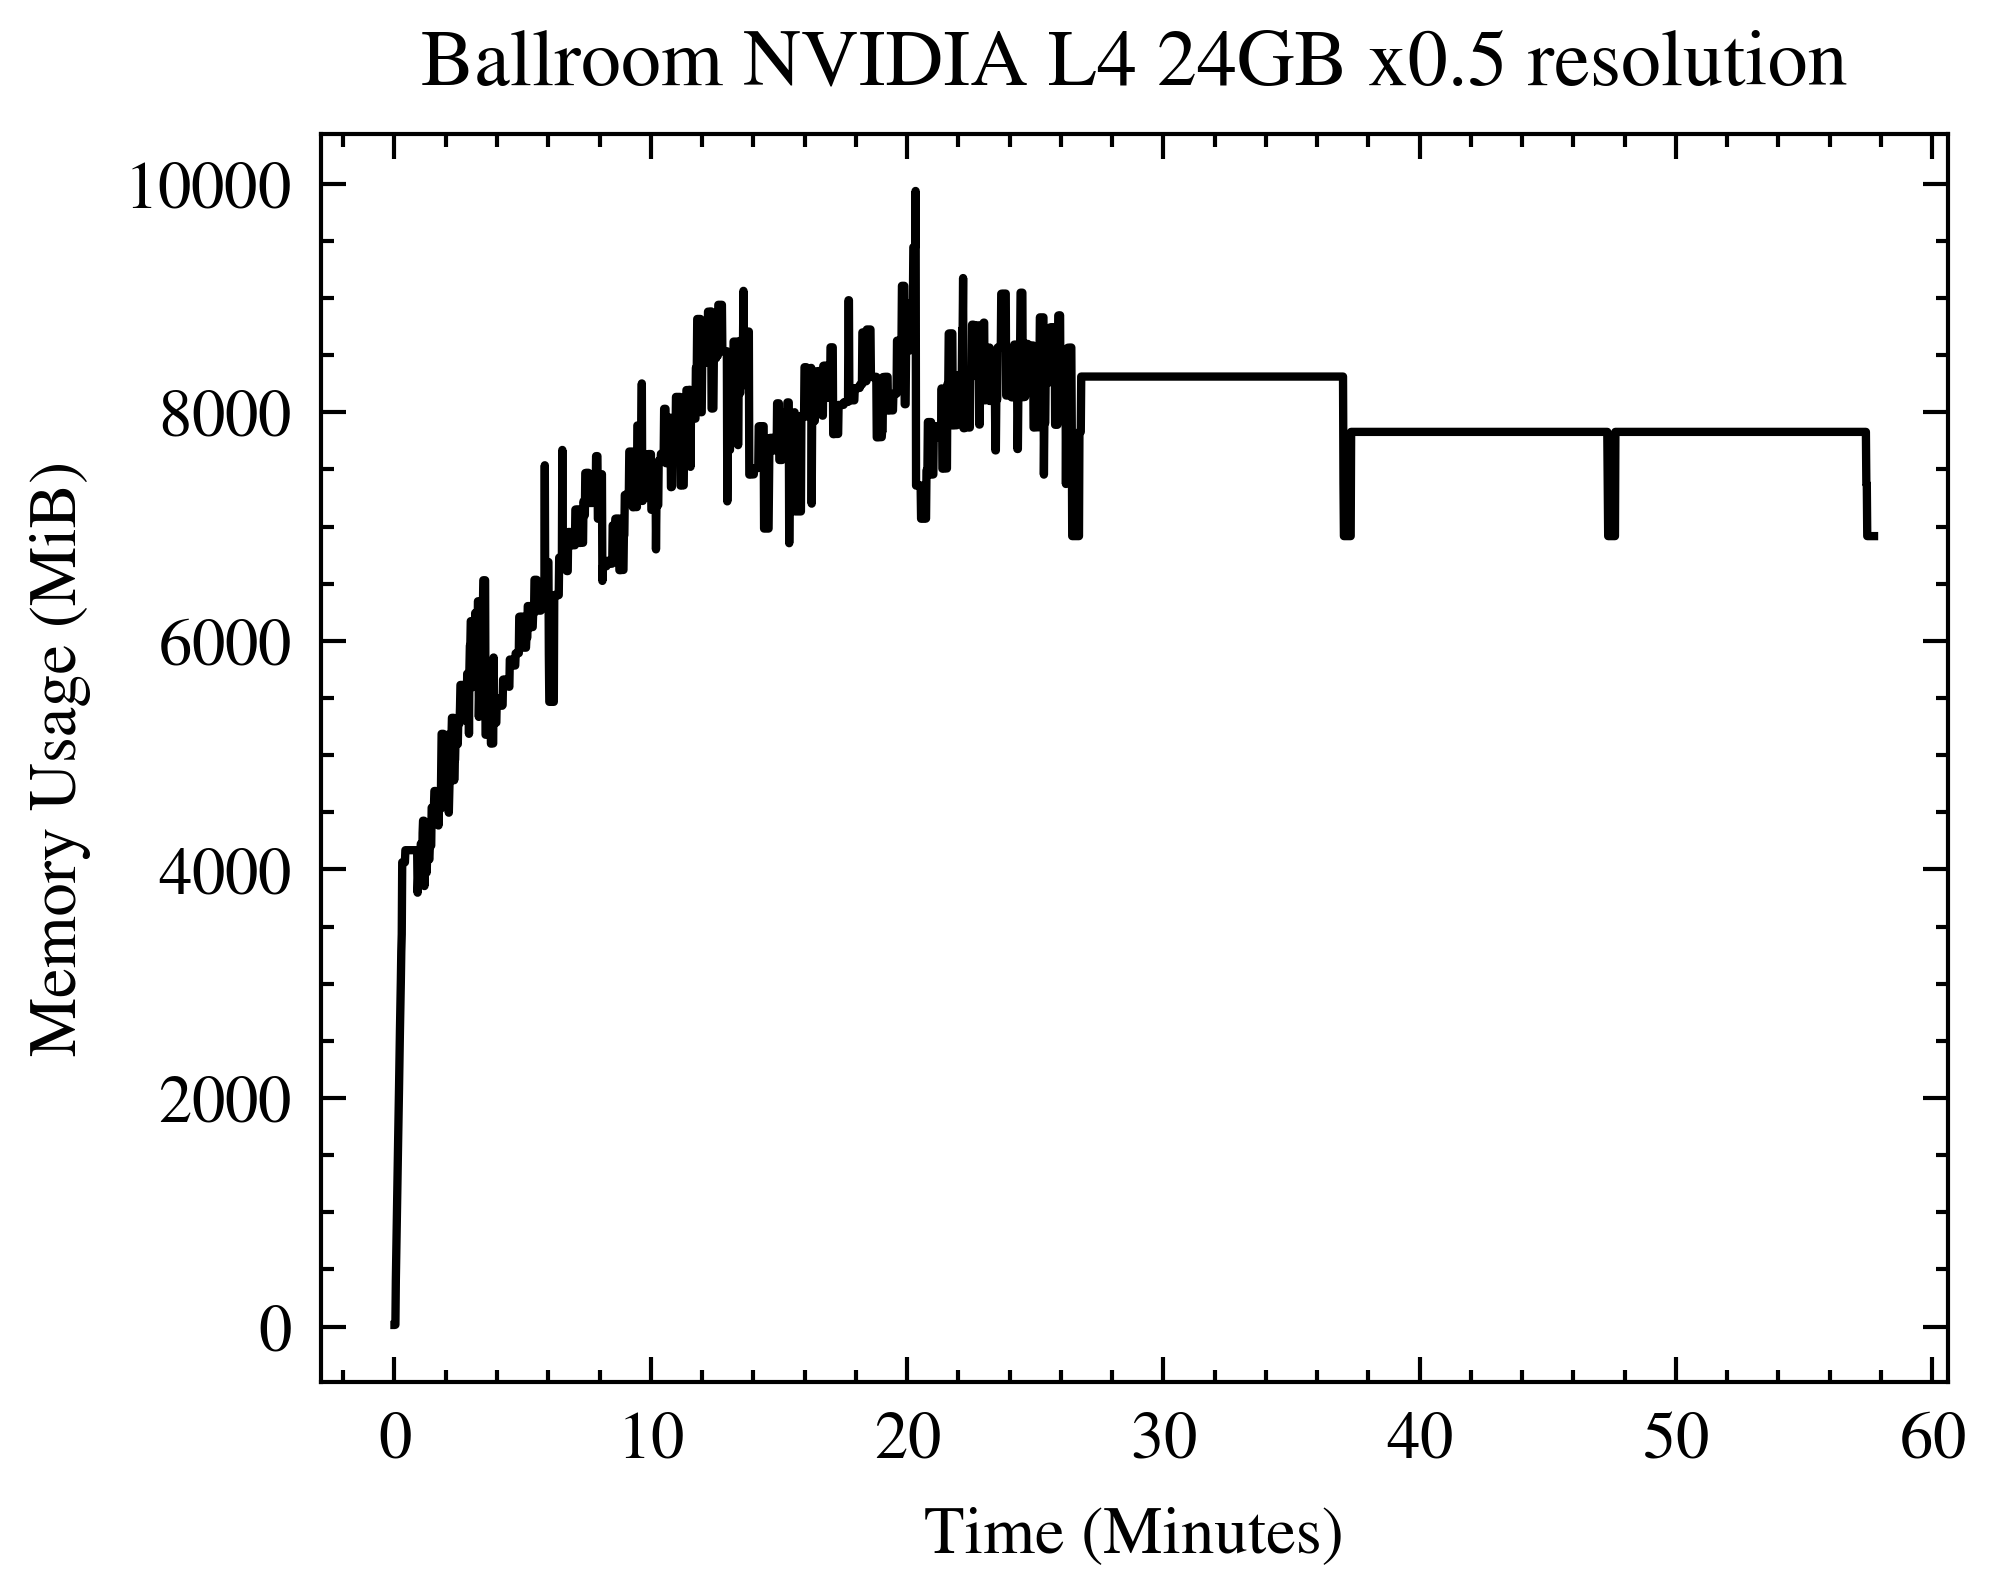

In [4]:
# graph plotting
sns.reset_orig()
plt.style.use(["science", "ieee", "no-latex"])
data = router(root / "ballroom_L4_24G_2.csv")
data = data[["Memory_Used_MiB","Time_Minutes"]]
fig, ax = plt.subplots(figsize=(3.5, 2.7))
sns.lineplot(
    data=data,
    y="Memory_Used_MiB",       # Time or sequence column
    x="Time_Minutes",       # Metric column
)
ax.set_ylabel("Memory Usage (MiB)")
ax.set_xlabel("Time (Minutes)")
ax.set_title("Ballroom NVIDIA L4 24GB x0.5 resolution")
ax.plot();
plt.show()

# Final Metrics to apply
## VRAM Accelaration Rate
Calculates Densification Memory Slope (DMS) to calculate how fast is VRAM being consumed during Adaptive Density Control Phase, also in some cases help to find when training will throw catastrophic CUDA Out-Of-Memory (OOM) error
$$\text{DMS} = \frac{V_{\text{peak}} - V_{\text{baseline}}}{T_{\text{plateau}} - T_{\text{start}}} \quad [\text{MiB / Minute}]$$

## Quality Energy Efficiency
Used to calculate how much power is spent to gain the Final PSNR/SSIM/LPIPS value

$$E_{\text{total}} = \int_{0}^{T} P(t) \, dt \approx \sum_{i=1}^{N} P_i \cdot \Delta t$$
$$\text{PSNR Efficiency} = \frac{\text{Final PSNR}}{E_{\text{total}}\times 10^-3} \quad \left[\text{dB/kJ}\right]$$
$$\text{SSIM Efficiency} = \frac{\text{Final SSIM}}{E_{\text{total}}\times 10^-3} \quad \left[\text{1/kJ}\right]$$
$$\text{LPIPS Efficiency} = \frac{1 - \text{Final LPIPS}}{E_{\text{total}}\times 10^-3} \quad \left[\text{1/kJ}\right]$$

## Convergence efficiency (Rate of Improvement)
To calculate how fast model is changing its PSNR and SSIM
$$\frac{d(\text{PSNR})}{d(\text{Iter})} \approx \frac{\text{PSNR}_{i} - \text{PSNR}_{i-5000}}{5000}$$

## Mean Compute Saturation (GPU Computer core saturation)
Average usage of GPU cores during training run
$$\mu_{\text{util}} = \frac{1}{N} \sum_{i=1}^{N} U_i$$


In [5]:
def calculate_dms(df):
    """
    Calculates the Densification Memory Slope (DMS) dynamically.
    Expects columns: 'Memory_Used_MiB' and 'Time_Minutes'
    """
    total_rows = len(df)
    
    # 1. Dynamic Baseline Detection (Using Statistical Mode)
    # We expand the window to 10% to ensure we capture the stable plateau
    search_window = max(20, int(total_rows * 0.10)) 
    
    # Find the most frequently occurring VRAM values in that early window
    baseline_candidates = df['Memory_Used_MiB'].iloc[:search_window].mode()
    
    # If there is a tie, take the max to ensure we get the fully loaded baseline
    v_baseline = baseline_candidates.max() 
    
    # 2. Peak VRAM Detection
    v_peak = df['Memory_Used_MiB'].max()
    
    # 3. Start Time (T_start) Detection
    # We add 100 MiB to the stable baseline to detect the actual densification climb
    start_threshold = v_baseline + 100 
    df_active = df[df['Memory_Used_MiB'] > start_threshold]
    
    minute_one_vram = df[df['Time_Minutes'] >= 1.0]['Memory_Used_MiB'].iloc[0]
    if minute_one_vram > (v_peak * 0.95):
        print("CRITICAL WARNING: Zero-Runway Initialization Detected.")
        print("The initial dataset footprint saturated the VRAM before Phase 4 could begin.")
        return "Initialization Choke (No DMS)"
    
    if df_active.empty:
        return "No densification detected (Flatline)"
        
    t_start = df_active['Time_Minutes'].iloc[0]
    
    # 4. Plateau Time (T_plateau) Detection
    t_plateau = df[df['Memory_Used_MiB'] == v_peak]['Time_Minutes'].iloc[0]
    
    # 5. DMS Math
    time_delta = t_plateau - t_start
    if time_delta <= 0:  
        return "Instantaneous Crash"
        
    dms = (v_peak - v_baseline) / time_delta
    
    # Formal extraction printout
    print("-" * 30)
    print("DMS Variable Extraction:")
    print(f"Total rows scanned: {total_rows}")
    print(f"V_baseline:  {v_baseline:.1f} MiB (Found via Mode)")
    print(f"V_peak:      {v_peak:.1f} MiB")
    print(f"T_start:     {t_start:.3f} Minutes")
    print(f"T_plateau:   {t_plateau:.3f} Minutes")
    print("-" * 30)
    print(f"Densification Memory Slope (DMS): {dms:.2f} MiB/Min")
    
    return dms

In [ ]:
def plot_dms_curve(df, title="VRAM Scaling", gpu_max_vram=None):
    """
    Calculates the DMS dynamically, handles OOM/Initialization anomalies, 
    and plots the IEEE-formatted graph.
    """
    total_rows = len(df)
    v_peak = df['Memory_Used_MiB'].max()
    
    # Optional: Automatically set the Y-axis ceiling if the user provides the GPU limit
    y_max = gpu_max_vram if gpu_max_vram else v_peak * 1.15

    # --- 1. SAFELY CHECK FOR ZERO-RUNWAY INITIALIZATION ---
    is_zero_runway = False
    df_minute_one = df[df['Time_Minutes'] >= 1.0]
    
    if not df_minute_one.empty:
        minute_one_vram = df_minute_one['Memory_Used_MiB'].iloc[0]
        if minute_one_vram > (v_peak * 0.95):
            is_zero_runway = True

    # --- 2. IEEE PLOTTING SETUP ---
    try:
        plt.style.use(["science", "ieee", "no-latex"])
    except:
        pass 

    fig, ax = plt.subplots(figsize=(3.5, 2.7))
    sns.lineplot(data=df, y="Memory_Used_MiB", x="Time_Minutes", ax=ax, color="#1f77b4", linewidth=1.2, label="VRAM Allocation")

    # --- 3. CONDITIONAL PLOTTING (Based on Anomaly) ---
    bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9)

    if is_zero_runway:
        # What to draw if the dataset is too heavy to even start
        ax.text(0.5, 0.5, "Zero-Runway Initialization\n(Densification Impossible)", transform=ax.transAxes, fontsize=7, va='center', ha='center', bbox=bbox_props, color="red")
        ax.scatter([df['Time_Minutes'].iloc[0]], [v_peak], color='red', zorder=5, marker='X', s=20, label="Instant Saturation")
    else:
        # --- NORMAL DMS MATH (Only run if it didn't choke at iteration 0) ---
        search_window = max(20, int(total_rows * 0.10)) 
        baseline_candidates = df['Memory_Used_MiB'].iloc[:search_window].mode()
        v_baseline = baseline_candidates.max() 
        
        start_threshold = v_baseline + 100 
        df_active = df[df['Memory_Used_MiB'] > start_threshold]
        
        if df_active.empty:
            print("Graphing Error: No densification detected, and it's not a Zero-Runway choke. Check your CSV.")
            plt.close()
            return
            
        t_start = df_active['Time_Minutes'].iloc[0]
        t_plateau = df[df['Memory_Used_MiB'] == v_peak]['Time_Minutes'].iloc[0]
        time_delta = t_plateau - t_start
        
        if time_delta > 0:
            dms = (v_peak - v_baseline) / time_delta
            # Draw the secant line and markers
            ax.plot([t_start, t_plateau], [v_baseline, v_peak], color="#d62728", linestyle="--", linewidth=1.5, label="DMS Trajectory")
            ax.scatter([t_start], [v_baseline], color='green', zorder=5, marker='o', s=15, label="Phase 4 Start")
            ax.scatter([t_plateau], [v_peak], color='red', zorder=5, marker='X', s=20, label="Phase 4 End / Choke")
            ax.text(0.5, 0.5, f"DMS: {dms:,.0f} MiB/Min", transform=ax.transAxes, fontsize=7, va='center', ha='left', bbox=bbox_props)
        else:
            # It crashed violently in under a minute
            ax.text(0.5, 0.5, "Catastrophic OOM Crash\n(Instantaneous)", transform=ax.transAxes, fontsize=7, va='center', ha='center', bbox=bbox_props, color="red")

    # --- 4. FORMATTING ---
    ax.set_ylabel("Memory Usage (MiB)")
    ax.set_xlabel("Time (Minutes)")
    ax.set_title(title)
    ax.legend(loc="lower right", fontsize=6)
    ax.grid(True, linestyle=":", alpha=0.6)
    
    ax.set_ylim(0, y_max) 

    plt.tight_layout()
    plt.show()

In [20]:
# plot_dms_curve(router(root / "exceeded_tank_rtx3060_12G_2.csv"),title="Exceeded sample")
# calculate_dms(router(root / "temple_rtx3060_12G_2.csv"))
calculate_dms(router(root / "tank_rtx3060_12G_4.csv"))
calculate_dms(router(root / "tank_rtx3060_12G_8.csv"))


          Dataset Name: tank
          GPU: RTX3060
          Video Memory: 12288 MiB
          Time Taken: 51.5017
          Resolution: 0.25 of 4300 x 2189 (1075 x 547)
          
          
------------------------------
DMS Variable Extraction:
Total rows scanned: 2940
V_baseline:  4606.0 MiB (Found via Mode)
V_peak:      7386.0 MiB
T_start:     4.235 Minutes
T_plateau:   26.642 Minutes
------------------------------
Densification Memory Slope (DMS): 124.07 MiB/Min

          Dataset Name: tank
          GPU: RTX3060
          Video Memory: 12288 MiB
          Time Taken: 28.3173
          Resolution: 0.125 of 4300 x 2189 (537 x 273)
          
          
------------------------------
DMS Variable Extraction:
Total rows scanned: 1558
V_baseline:  1012.0 MiB (Found via Mode)
V_peak:      3567.0 MiB
T_start:     1.914 Minutes
T_plateau:   12.566 Minutes
------------------------------
Densification Memory Slope (DMS): 239.87 MiB/Min


239.87231845280007